In [7]:
import re, math, warnings
warnings.filterwarnings('ignore')
from collections import Counter
from itertools import islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

wiki = load_dataset('wikimedia/wikipedia', '20231101.pl', split='train', streaming=True)
articles = list(islice(wiki, 200))
texts  = [a['text']  for a in articles]
titles = [a['title'] for a in articles]
print(f"Załadowano {len(texts)} artykułów.")

README.md: 0.00B [00:00, ?B/s]

Załadowano 200 artykułów.


### Zadanie 1: Pierwsza eksploracja korpusu
Korzystajac z zaladowanych 200 artykulow Wikipedii PL:

* Wyswietl tytuły pierwszych 10 artykulow.
* Dla kazdego z 10 artykulow wydrukuj: tytul, liczbe slow, pierwsze 2 zdania tekstu.
* Znajdz i wyswietl: najkrotszy i najdluzszy artykul (w slowach).
* W komórce Markdown: czym rozni sie korpus jezykowy od zbioru danych do
klasyfikacji?
(odpowiedz wlasnym slowami, 3–5 zdan)

In [ ]:
# Zadanie 1
# 1) Tytuly pierwszych 10 artykulow
print('Pierwsze 10 tytulow:')
for i, t in enumerate(titles[:10], 1):
    print(f"{i:02d}. {t}")

# 2) Dla kazdego: tytul, liczba slow, pierwsze 2 zdania
sentence_splitter = re.compile(r'(?<=[.!?])\s+')
print('\nSzczegoly dla 10 artykulow:')
for i, (title, text) in enumerate(zip(titles[:10], texts[:10]), 1):
    word_count = len(text.split())
    sentences = [s.strip() for s in sentence_splitter.split(text) if s.strip()]
    first_two = ' '.join(sentences[:2]) if sentences else '(brak zdan)'
    print(f"\n[{i:02d}] {title}")
    print(f"Liczba slow: {word_count}")
    print(f"Pierwsze 2 zdania: {first_two[:500]}")

# 3) Najkrotszy i najdluzszy artykul
word_lengths = [len(t.split()) for t in texts]
min_idx = int(np.argmin(word_lengths))
max_idx = int(np.argmax(word_lengths))

print('\nNajkrotszy artykul:')
print(f"Tytul: {titles[min_idx]}")
print(f"Liczba slow: {word_lengths[min_idx]}")

print('\nNajdluzszy artykul:')
print(f"Tytul: {titles[max_idx]}")
print(f"Liczba slow: {word_lengths[max_idx]}")


Korpus jezykowy to szeroki, reprezentatywny zbior tekstow, ktory ma odzwierciedlac realny jezyk i sluzyc do ogolnej analizy lub uczenia modeli jezykowych.
Zbior danych do klasyfikacji jest zwykle wezszy i przygotowany pod konkretne zadanie, np. sentyment, spam albo tematyke.
W klasyfikacji kluczowe sa etykiety i balans klas, a w korpusie jezykowym wazniejsza bywa roznorodnosc stylow, domen i slownictwa.
Inaczej mowiac: kazdy zbior do klasyfikacji jest danymi tekstowymi, ale nie kazdy korpus jest gotowym zbiorem do klasyfikacji.


### Zadanie 2: Statystyki leksykalne i prawo Zipfa

Na pelnym zbiorze 200 artykulow:
* Polacz wszystkie teksty, przeprowadz prosta tokenizacje (split po bialych znakach,
lowercase, usun interpunkcje za pomoca re.sub).
* Oblicz i wyswietl: laczna liczba tokenow, liczba unikalnych tokenow (types), TTR.
* Wyswietl 20 najczestszych i 20 najrzadziej wystepujacych slow.
* Narysuj wykres prawa Zipfa: os X = ranga (log), os Y = czestotliwosc (log).

Na wykresie powinna wyjsc w przyblizeniu linia prosta — jesli nie, sprawdz tokenizacje.

In [ ]:
# Zadanie 2
# Tokenizacja: lowercase + usuniecie interpunkcji + split po bialych znakach
all_text = ' '.join(texts).lower()
all_text = re.sub(r'[^\w\s]', ' ', all_text)
all_tokens = all_text.split()

# Statystyki
total_tokens = len(all_tokens)
unique_tokens = len(set(all_tokens))
ttr = unique_tokens / total_tokens if total_tokens else 0.0

print(f'Laczna liczba tokenow: {total_tokens}')
print(f'Liczba unikalnych tokenow (types): {unique_tokens}')
print(f'TTR: {ttr:.4f}')

freq = Counter(all_tokens)

# 20 najczestszych
most_common_20 = freq.most_common(20)
print('\n20 najczestszych slow:')
for tok, c in most_common_20:
    print(f'{tok:20s} -> {c}')

# 20 najrzadszych
rarest_20 = sorted(freq.items(), key=lambda x: (x[1], x[0]))[:20]
print('\n20 najrzadszych slow:')
for tok, c in rarest_20:
    print(f'{tok:20s} -> {c}')

# Wykres prawa Zipfa (log-log)
sorted_freqs = sorted(freq.values(), reverse=True)
ranks = np.arange(1, len(sorted_freqs) + 1)

plt.figure(figsize=(8, 5))
plt.loglog(ranks, sorted_freqs)
plt.title('Prawo Zipfa dla 200 artykulow Wikipedii PL')
plt.xlabel('Ranga (log)')
plt.ylabel('Czestotliwosc (log)')
plt.grid(True, which='both', alpha=0.3)
plt.show()


Prawo Zipfa oznacza, ze mala grupa bardzo czestych tokenow pokrywa duza czesc tekstu, a ogromna liczba tokenow wystepuje rzadko.
W praktyce dla LLM przeklada sie to na to, ze budzet tokenow szybko zuzywaja slowa funkcyjne i czeste frazy, a rzadsze slowa "kosztuja" model bardziej informacyjnie.
Dlatego przy projektowaniu promptow i chunkingu warto minimalizowac powtorzenia i dbac o wysoka gestosc informacji w kazdym tokenie.


### Zadanie 3: Rozklad dlugosci artykulow
* Oblicz dlugosc kazdego artykulu w slowach.
* Narysuj histogram (bins=30). Zaznacz mediame i P95 pionowymi liniami.
* Oblicz i wyswietl: min, max, srednia, mediana, odchylenie standardowe, P95.

In [ ]:
# Zadanie 3
article_lengths = np.array([len(t.split()) for t in texts])

min_len = int(article_lengths.min())
max_len = int(article_lengths.max())
mean_len = float(article_lengths.mean())
median_len = float(np.median(article_lengths))
std_len = float(article_lengths.std())
p95_len = float(np.percentile(article_lengths, 95))

plt.figure(figsize=(8, 5))
plt.hist(article_lengths, bins=30, edgecolor='black', alpha=0.75)
plt.axvline(median_len, color='red', linestyle='--', linewidth=2, label=f'Mediana: {median_len:.1f}')
plt.axvline(p95_len, color='green', linestyle='--', linewidth=2, label=f'P95: {p95_len:.1f}')
plt.title('Rozklad dlugosci artykulow (w slowach)')
plt.xlabel('Liczba slow')
plt.ylabel('Liczba artykulow')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f'min: {min_len}')
print(f'max: {max_len}')
print(f'srednia: {mean_len:.2f}')
print(f'mediana: {median_len:.2f}')
print(f'odchylenie standardowe: {std_len:.2f}')
print(f'P95: {p95_len:.2f}')

# Szacunek dla BERT: 1 slowo ~ 1.3 tokenu
estimated_tokens = article_lengths * 1.3
to_truncate = int((estimated_tokens > 512).sum())
print(f'\nSzacowana liczba artykulow przekraczajacych 512 tokenow: {to_truncate} / {len(article_lengths)}')


Liczbe artykulow wymagajacych obciecia dostajesz bezposrednio z wyniku poprzedniej komorki (`to_truncate`).
Szacunek opiera sie na przyblizeniu 1 slowo ~ 1.3 tokenu, wiec granica to okolo 394 slow na artykul (394 * 1.3 ~= 512).
Jesli takich artykulow jest duzo, to obciecie moze byc problemem, bo tracisz kontekst z konca dokumentu i mozesz pogorszyc jakosc predykcji.
Wtedy lepiej stosowac chunking (dzielenie dokumentu na fragmenty) albo modele obslugujace dluzszy kontekst.


### Zadanie 4: Tokenizacja polska a angielska
Polszczyzna jest morfologicznie bogata — sprawdz, jak tokenizatory sobie z nia radza.

Wybierz 10 zdan z korpusu (mozesz uzyc pierwszych 10 zdan z pierwszego artykulu).
Dla kazdego zdania zastosuj dwa tokenizatory:
* allegro/herbert-base-cased (WordPiece trenowany na polskim)
* bert-base-multilingual-cased (mBERT — wielojezyczny)
Dla kazdego zdania wyswietl tokeny obu modeli i liczbe tokenow.
Stworz DataFrame (pandas) z kolumnami: zdanie, herbert_n, mbert_n, roznica.
* Narysuj barplot: liczba tokenow herbert vs mbert dla kazdego zdania.

In [ ]:
# Zadanie 4
from transformers import AutoTokenizer
from IPython.display import display

# Bierzemy 10 zdan z pierwszego artykulu
sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', texts[0]) if s.strip()][:10]

tok_herbert = AutoTokenizer.from_pretrained('allegro/herbert-base-cased')
tok_mbert = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')

rows = []
print('Porownanie tokenizacji (10 zdan):')
for i, sent in enumerate(sentences, 1):
    h_tokens = tok_herbert.tokenize(sent)
    m_tokens = tok_mbert.tokenize(sent)

    print(f"\nZdanie {i}: {sent}")
    print(f"HerBERT ({len(h_tokens)}): {h_tokens}")
    print(f"mBERT   ({len(m_tokens)}): {m_tokens}")

    rows.append({
        'zdanie': sent,
        'herbert_n': len(h_tokens),
        'mbert_n': len(m_tokens),
        'roznica': len(m_tokens) - len(h_tokens)
    })

df_tok = pd.DataFrame(rows)
display(df_tok)

# Barplot porownawczy
x = np.arange(len(df_tok))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, df_tok['herbert_n'], width, label='HerBERT')
plt.bar(x + width/2, df_tok['mbert_n'], width, label='mBERT')
plt.title('Liczba tokenow na zdanie: HerBERT vs mBERT')
plt.xlabel('Index zdania')
plt.ylabel('Liczba tokenow')
plt.xticks(x, [str(i + 1) for i in x])
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()


W praktyce dla polskiego czesciej bardziej efektywny bywa HerBERT, bo jego tokenizer byl trenowany na polskich danych i zwykle dzieli zdania na mniej subtokenow.
Mniej tokenow dla tej samej tresci oznacza nizszy koszt obliczeniowy i wiecej informacji mieszczacej sie w limicie kontekstu.
Wiekszy slownik subslow moze poprawiac pokrycie form fleksyjnych (mniej podzialow), ale zwieksza pamiec i zlozonosc modelu.
Mniejszy slownik daje lzejszy model, ale czesciej rozbija wyrazy na wiele fragmentow, co moze utrudniac reprezentacje znaczenia.


### Zadanie 5: N-gramy i kolokacje
N-gram to ciag N kolejnych tokenow. Bigram = 2 tokeny, trigram = 3.
Czesc A — bigramy:
* Dla wszystkich 200 artykulow polacz tokeny w liste i oblicz czestotliwosc
bigramow.
* Wyswietl 20 najczestszych bigramow. Czy sa sensowne? Jakie widac wzorce?
Czesc B — trigramy:
* Powtorz dla trigramow (N=3). Wyswietl top 15.
Czesc C — porownanie po usunieciu stopslów:
* Zaladuj liste polskich stopslów: pip install stop_words,
from stop_words import get_stop_words; stopwords = get_stop_words('pl')
* Przefiltruj tokeny i ponownie oblicz top-20 bigramow.

In [ ]:
# Zadanie 5
# Czesc A i B: bigramy/trigramy na wszystkich tokenach
all_text = ' '.join(texts).lower()
all_text = re.sub(r'[^\w\s]', ' ', all_text)
tokens = all_text.split()

bigrams = list(zip(tokens, tokens[1:]))
trigrams = list(zip(tokens, tokens[1:], tokens[2:]))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

print('Top 20 bigramow:')
for bg, c in bigram_counts.most_common(20):
    print(f"{' '.join(bg):30s} -> {c}")

print('\nTop 15 trigramow:')
for tg, c in trigram_counts.most_common(15):
    print(f"{' '.join(tg):40s} -> {c}")

# Czesc C: po usunieciu stopslow
# Automatyczny fallback: doinstaluj pakiet, jesli go brakuje
try:
    from stop_words import get_stop_words
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'stop-words'])
    from stop_words import get_stop_words

pl_stopwords = set(get_stop_words('pl'))
filtered_tokens = [t for t in tokens if t not in pl_stopwords]
filtered_bigrams = list(zip(filtered_tokens, filtered_tokens[1:]))
filtered_bigram_counts = Counter(filtered_bigrams)

print('\nTop 20 bigramow po usunieciu stopslow:')
for bg, c in filtered_bigram_counts.most_common(20):
    print(f"{' '.join(bg):30s} -> {c}")


Usuniecie stopwords zwykle poprawia czytelnosc kolokacji, bo znikaja bardzo czeste, malo informacyjne polaczenia typu "w roku", "i na".
Dzieki temu latwiej zobaczyc frazy niosace tresc merytoryczna, np. nazwy wlasne, terminy domenowe i stale wyrazenia.
Stopwords warto usuwac w analizie eksploracyjnej, slowach kluczowych, tematach czy klasycznych cechach BoW/TF-IDF.
Lepiej je zostawic tam, gdzie relacje skladniowe sa kluczowe (dependency parsing) oraz przy trenowaniu modeli jezykowych, bo slowa funkcyjne niosa strukture gramatyczna.


## Zalaczniki (wykresy)\n\n### Prawo Zipfa\n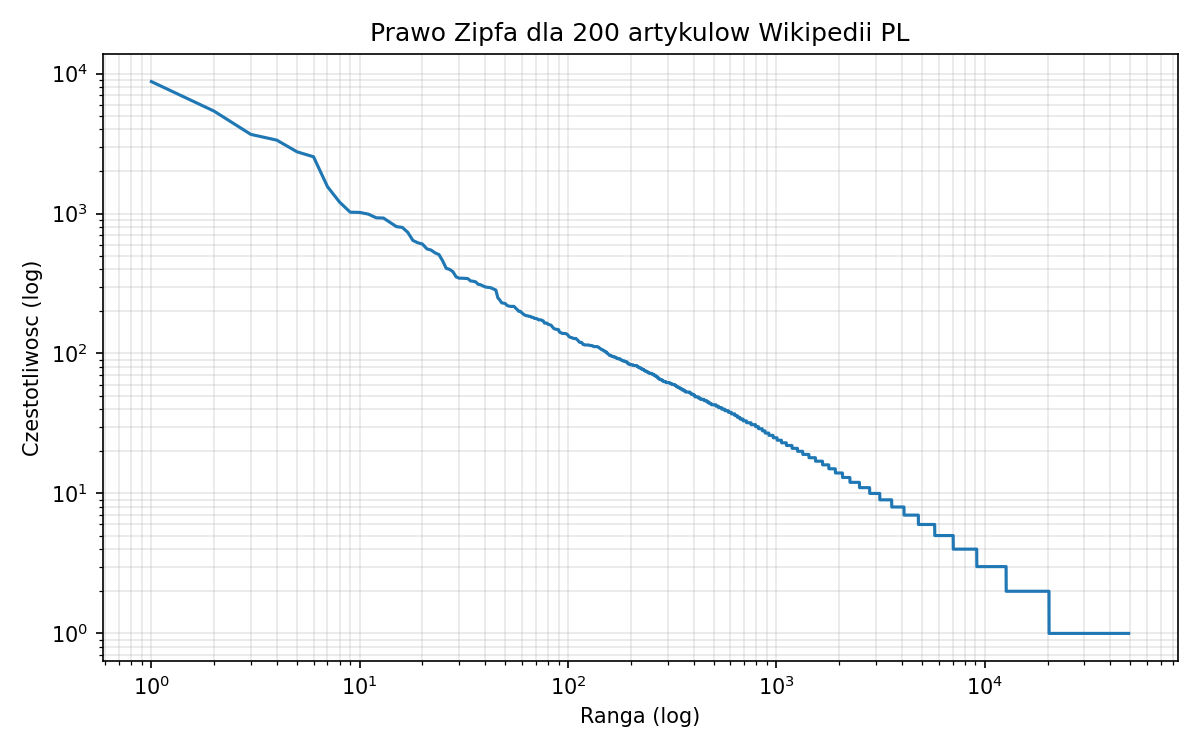\n\n### Rozklad dlugosci artykulow\n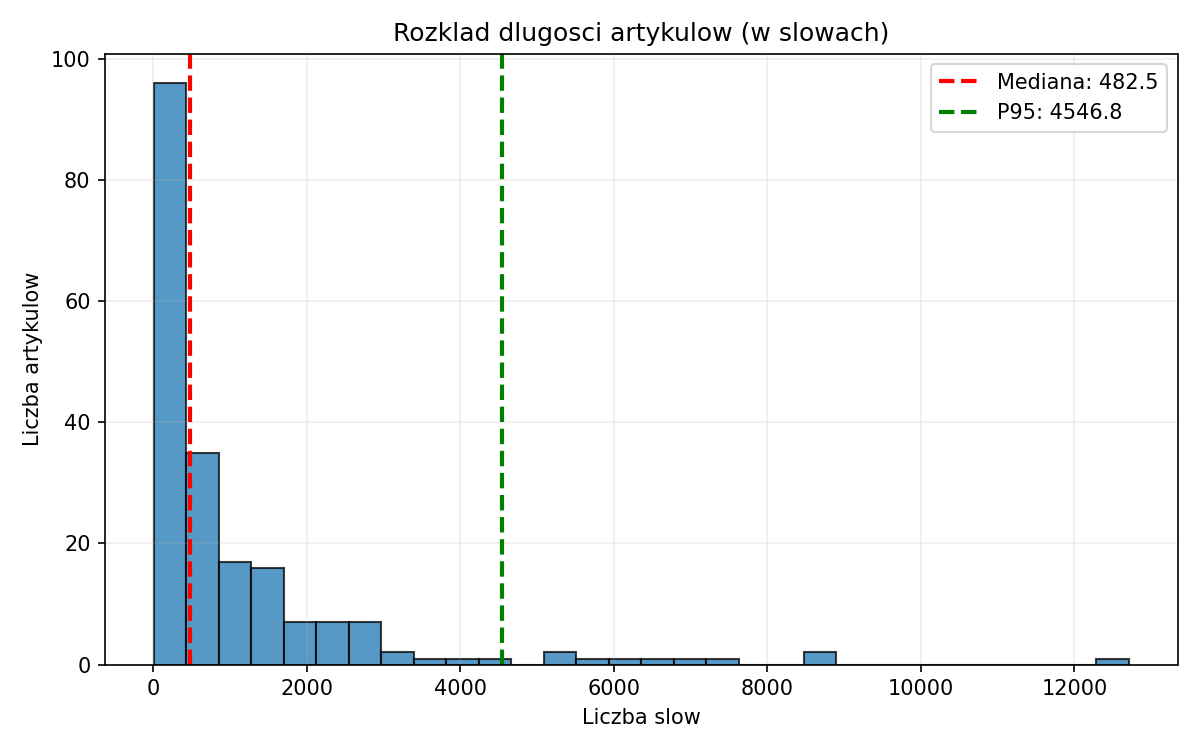\n\n### HerBERT vs mBERT\n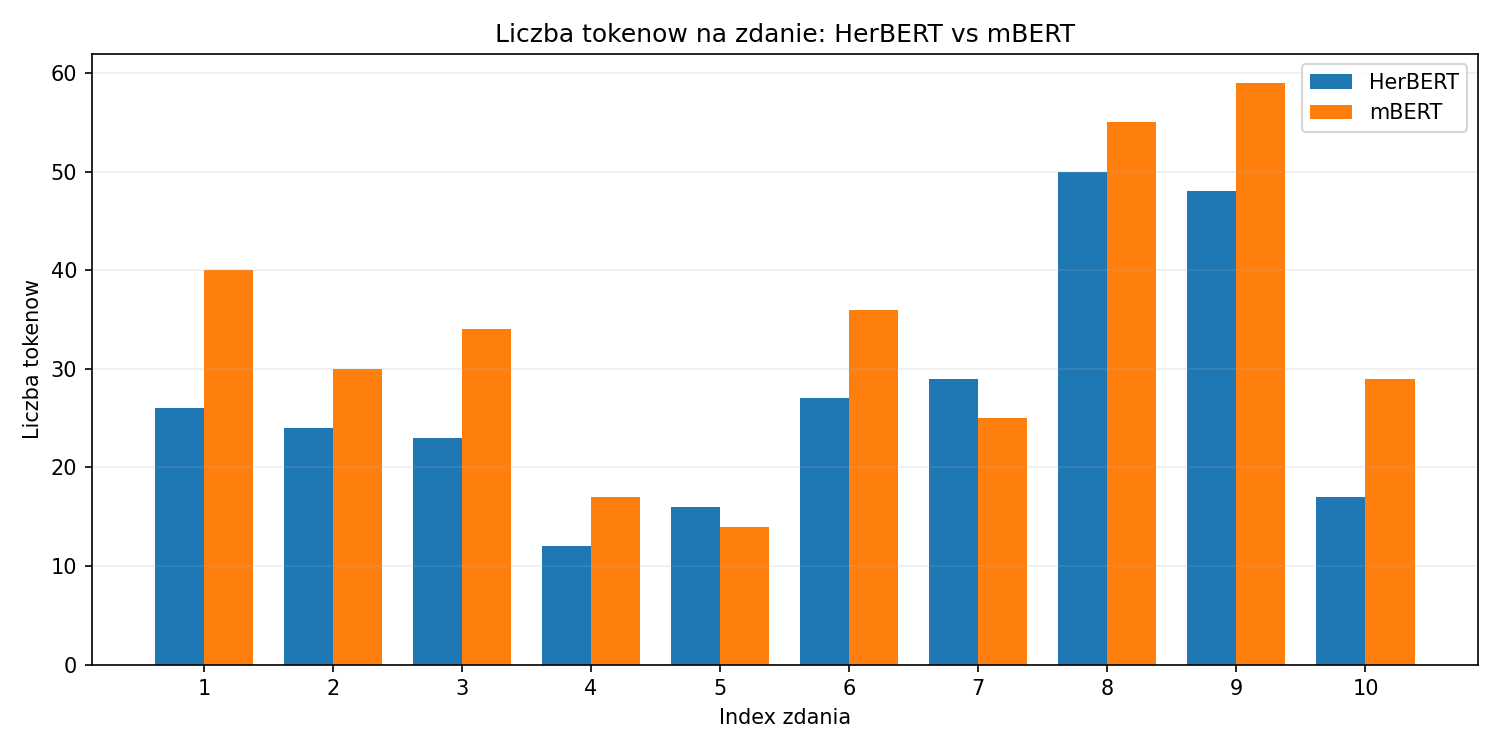\n